___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Finance Data Project 

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
** NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way! **
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

## Get the Data

In this section we will learn how to use pandas to directly read data from Google finance using pandas!

First we need to start with the proper imports, which we've already laid out for you here.

*Note: [You'll need to install pandas-datareader for this to work!](https://github.com/pydata/pandas-datareader) Pandas datareader allows you to [read stock information directly from the internet](http://pandas.pydata.org/pandas-docs/stable/remote_data.html) Use these links for install guidance (**pip install pandas-datareader**), or just follow along with the video lecture.*

### The Imports

Already filled out for you.

In [27]:
from pandas_datareader import data, wb
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

## Data

We need to get data using pandas datareader. We will get stock information for the following banks:
*  Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo

** Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**
1. Use datetime to set start and end datetime objects.
2. Figure out the ticker symbol for each bank.
2. Figure out how to use datareader to grab info on the stock.

** Use [this documentation page](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html) for hints and instructions (it should just be a matter of replacing certain values. Use google finance as a source, for example:**
    
    # Bank of America
    BAC = data.DataReader("BAC", 'google', start, end)

### WARNING: MAKE SURE TO CHECK THE LINK ABOVE FOR THE LATEST WORKING API. "google" MAY NOT ALWAYS WORK. 
------------
### We also provide pickle file in the article lecture right before the video lectures.

In [3]:
import yfinance as yf

In [3]:
bac = yf.download("BAC", start= '2006-01-01', end='2016-01-01')

[*********************100%***********************]  1 of 1 completed


In [7]:
bac.head()

Price,Close,High,Low,Open,Volume
Ticker,BAC,BAC,BAC,BAC,BAC
Date,,,,,
2006-01-03,30.330349,30.394771,29.731215,30.227270,16296700
2006-01-04,30.008221,30.433412,29.924470,30.278796,17757900
2006-01-05,30.046885,30.169290,29.840731,30.008232,14970700
2006-01-06,30.001791,30.220829,29.860060,30.149964,12599800
2006-01-09,30.021118,30.259485,29.866504,30.098428,15619400


In [9]:
c= yf.download('C', start='2006-01-01', end='2016-01-01')

[*********************100%***********************]  1 of 1 completed


In [11]:
gs= yf.download('GS', start='2006-01-01',end='2016-01-01')

[*********************100%***********************]  1 of 1 completed


In [13]:
jpm = yf.download('JPM', start='2006-01-01',end='2016-01-01')

[*********************100%***********************]  1 of 1 completed


In [15]:
ms =yf.download('MS', start='2006-01-01',end='2016-01-01')

[*********************100%***********************]  1 of 1 completed


In [17]:
wfc = yf.download('WFC', start='2006-01-01',end='2016-01-01')

[*********************100%***********************]  1 of 1 completed


** Create a list of the ticker symbols (as strings) in alphabetical order. Call this list: tickers**

In [19]:
tickers = ['BAC','C','GS','JPM','MS','WFC']

In [21]:
tickers

['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']

** Use pd.concat to concatenate the bank dataframes together to a single data frame called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to what axis you concatenate on.**

In [23]:
bank_stocks=pd.concat([bac,c,gs,jpm,ms,wfc], axis=1)

In [25]:
# 2. Swap the column levels so Ticker is level 0 and Price Info is level 1
bank_stocks = bank_stocks.swaplevel(axis=1)

** Set the column name levels (this is filled out for you):**

In [27]:
bank_stocks.columns.names = ['Bank Ticker','Stock Info']

In [29]:
bank_stocks.head()

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Date                                                                            
2006-01-03   30.330349  30.394771  29.731215  30.227270  16296700  314.316803   
2006-01-04   30.008221  30.433412  29.924470  30.278796  17757900  308.513733   
2006-01-05   30.046885  30.169290  29.840731  30.008232  14970700  310.044098   
2006-01-06   30.001791  30.220829  29.860060  30.149964  12599800  310.044098   
2006-01-09   30.021118  30.259485  29.866504  30.098428  15619400  308.577545   

Bank Ticker                                               ...         MS  \
Stock Info         High         Low        Open   Volume  ...      Close   
Date                                                      ...              
2006-01-03   314.890719  306.792083  312.467509  1537600  ...  31.182051   
2006-01-04   313.105099  308.322434  311.574650  1870960  ...  31.203430   
2006-01-05   311.064384  308.641176  308.896247  1143160  ...  31.289007   
2006-01-06   311.829618  307.365799  311.702072  1370210  ...  31.321091   
2006-01-09   310.809456  308.003629  309.916695  1680740  ...  31.652639   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Date                                                                          
2006-01-03   31.278308  30.342472  30.572419  5377000  18.274656  18.317622   
2006-01-04   31.700760  31.203430  31.390599  7977800  18.062706  18.228839   
2006-01-05   31.331789  31.026974  31.310398  5778000  18.042645  18.077017   
2006-01-06   31.470824  31.043013  31.428044  6889800  18.148634  18.203057   
2006-01-09   31.706117  31.347824  31.353173  4144500  18.145760  18.231691   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Date                                         
2006-01-03   17.870781  18.102795  11016400  
2006-01-04   17.968181  18.217381  10870000  
2006-01-05   17.936662  18.045508  10158000  
2006-01-06   17.979636  18.091346   8403800  
2006-01-09   18.077015  18.145760   5619600  

[5 rows x 30 columns]

** Check the head of the bank_stocks dataframe.**

Bank Ticker    BAC                                     C                       \
Stock Info    Open   High    Low  Close    Volume   Open   High    Low  Close   
Date                                                                            
2006-01-03   46.92  47.18  46.15  47.08  16296700  490.0  493.8  481.1  492.9   
2006-01-04   47.00  47.24  46.45  46.58  17757900  488.6  491.0  483.5  483.8   
2006-01-05   46.58  46.83  46.32  46.64  14970900  484.4  487.8  484.0  486.2   
2006-01-06   46.80  46.91  46.35  46.57  12599800  488.8  489.0  482.0  486.2   
2006-01-09   46.72  46.97  46.36  46.60  15620000  486.0  487.4  483.0  483.9   

Bank Ticker             ...        MS                                  WFC  \
Stock Info    Volume    ...      Open   High    Low  Close   Volume   Open   
Date                    ...                                                  
2006-01-03   1537660    ...     57.17  58.49  56.74  58.31  5377000  31.60   
2006-01-04   1871020    ...     58.70  59.28  58.35  58.35  7977800  31.80   
2006-01-05   1143160    ...     58.55  58.59  58.02  58.51  5778000  31.50   
2006-01-06   1370250    ...     58.77  58.85  58.05  58.57  6889800  31.58   
2006-01-09   1680740    ...     58.63  59.29  58.62  59.19  4144500  31.68   

Bank Ticker                                 
Stock Info    High    Low  Close    Volume  
Date                                        
2006-01-03   31.98  31.20  31.90  11016400  
2006-01-04   31.82  31.36  31.53  10871000  
2006-01-05   31.56  31.31  31.50  10158000  
2006-01-06   31.78  31.38  31.68   8403800  
2006-01-09   31.82  31.56  31.68   5619600  

[5 rows x 30 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check out the documentation on [Multi-Level Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [Using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Reference the solutions if you can not figure out how to use .xs(), since that will be a major part of this project.

** What is the max Close price for each bank's stock throughout the time period?**

Bank Ticker
BAC     54.90
C      564.10
GS     247.92
JPM     70.08
MS      89.30
WFC     58.52
dtype: float64

In [31]:
bank_stocks.xs('Close', level = 'Stock Info', axis=1).max()

Bank Ticker
BAC     36.679707
C      374.732574
GS     181.499557
JPM     52.581127
MS      48.881325
WFC     43.081253
dtype: float64

** Create a new empty DataFrame called returns. This dataframe will contain the returns for each bank's stock. returns are typically defined by:**

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [33]:
returns = pd.DataFrame()

In [35]:
df2 = bank_stocks.xs('Close', level = 'Stock Info', axis = 1)
# sort again df2 to follow date ASC order
df2 = df2.sort_values('Date')
df2

Bank Ticker,BAC,C,GS,JPM,MS,WFC
Date,,,,,,
2006-01-03,30.330349,314.316803,92.949364,23.633686,31.182051,18.274656
2006-01-04,30.008221,308.513733,91.665504,23.497280,31.203430,18.062706
2006-01-05,30.046885,310.044098,91.629425,23.568457,31.289007,18.042645
2006-01-06,30.001791,310.044098,92.927727,23.734497,31.321091,18.148634
2006-01-09,30.021118,308.577545,94.045662,24.119995,31.652639,18.145760
...,...,...,...,...,...,...
2015-12-24,13.721889,38.984730,147.278793,50.330627,24.204792,40.900063
2015-12-28,13.610649,38.740639,146.592743,50.164375,23.973774,40.795612
2015-12-29,13.729827,39.184402,148.134430,50.685822,24.256954,41.250732


In [37]:
# to use the shift function (get the value of the same column, time t-n*shift), we need to sort the dataframe first
df2['previous_value'] = df2['BAC'].shift(1)

In [39]:
# now remove the column
df2=df2.drop('previous_value', axis=1)
df2.head()

Bank Ticker,BAC,C,GS,JPM,MS,WFC
Date,,,,,,
2006-01-03,30.330349,314.316803,92.949364,23.633686,31.182051,18.274656
2006-01-04,30.008221,308.513733,91.665504,23.497280,31.203430,18.062706
2006-01-05,30.046885,310.044098,91.629425,23.568457,31.289007,18.042645
2006-01-06,30.001791,310.044098,92.927727,23.734497,31.321091,18.148634
2006-01-09,30.021118,308.577545,94.045662,24.119995,31.652639,18.145760


In [41]:
for x in tickers:
    t = '{} Return'.format(x)
    returns[t]= df2[x].pct_change()

In [43]:
returns

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010621,-0.018462,-0.013812,-0.005772,0.000686,-0.011598
2006-01-05,0.001288,0.004960,-0.000394,0.003029,0.002743,-0.001111
2006-01-06,-0.001501,0.000000,0.014169,0.007045,0.001025,0.005874
2006-01-09,0.000644,-0.004730,0.012030,0.016242,0.010585,-0.000158
...,...,...,...,...,...,...
2015-12-24,-0.004036,0.001521,-0.002624,-0.001948,-0.003681,-0.003997
2015-12-28,-0.008107,-0.006261,-0.004658,-0.003303,-0.009544,-0.002554
2015-12-29,0.008756,0.011455,0.010517,0.010395,0.011812,0.011156


** We can use pandas pct_change() method on the Close column to create a column representing this return value. Create a for loop that goes and for each Bank Stock Ticker creates this returns column and set's it as a column in the returns DataFrame.**

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.014183,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.000951
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005714
2006-01-09,0.000644,-0.004731,0.012030,0.016242,0.010586,0.000000


** Create a pairplot using seaborn of the returns dataframe. What stock stands out to you? Can you figure out why?**

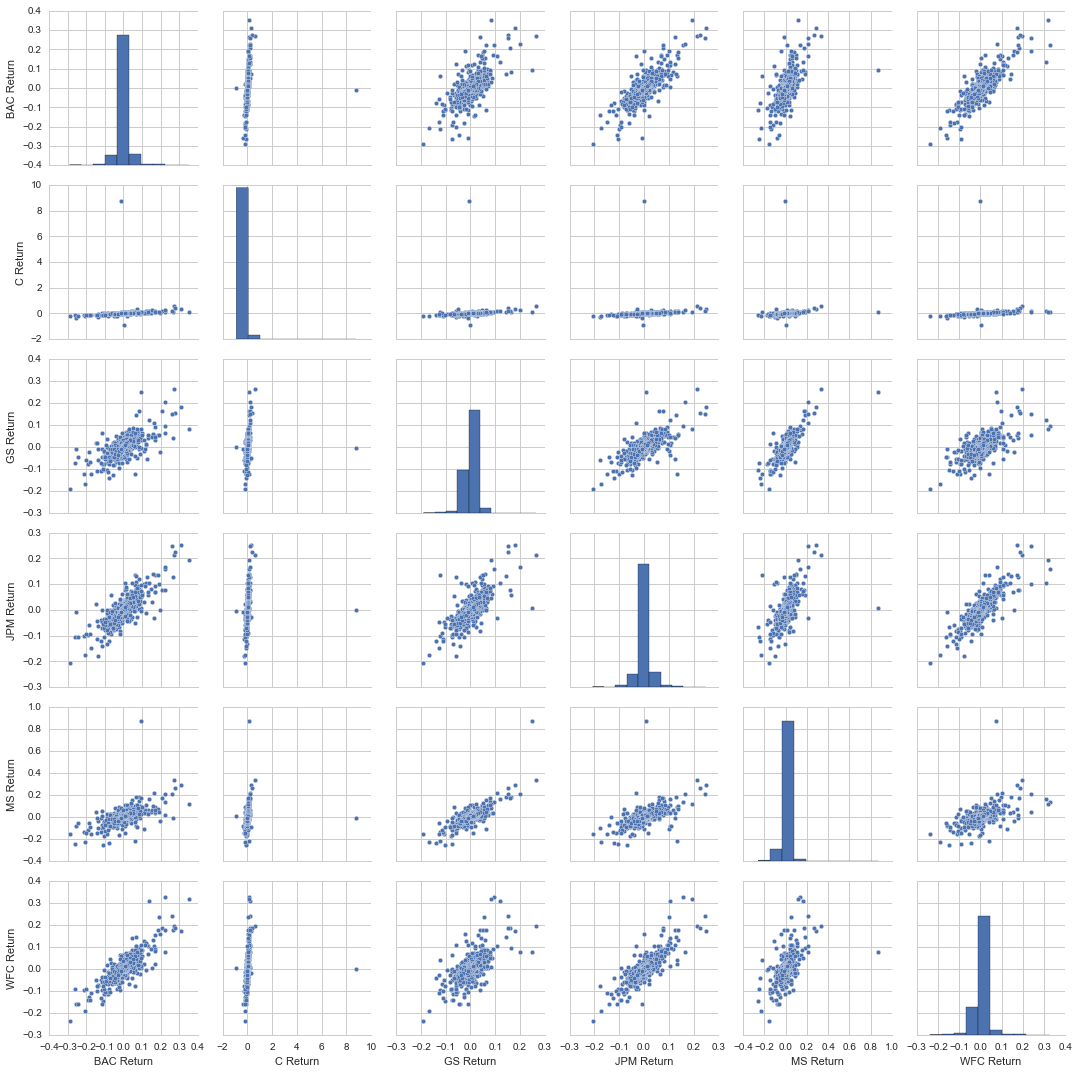

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

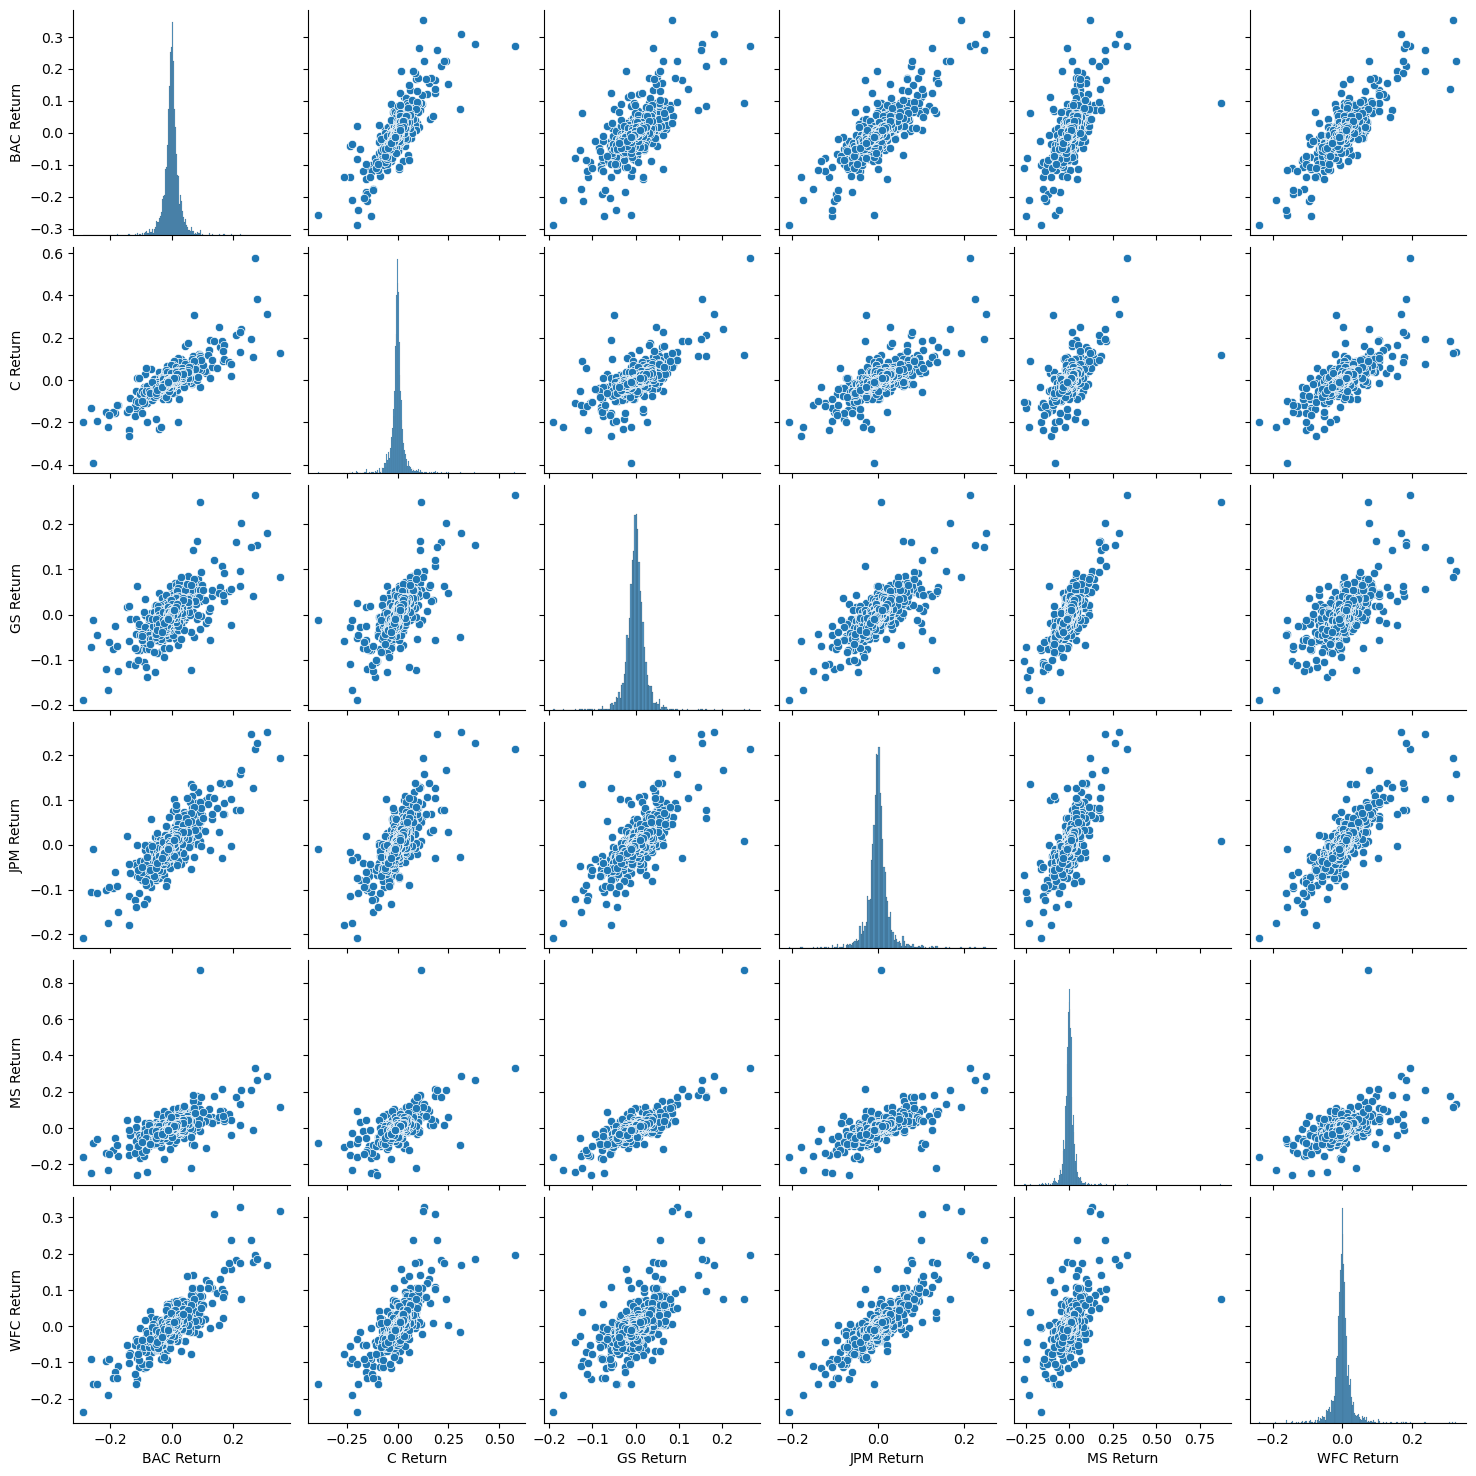

In [47]:
sns.pairplot(data=returns)
plt.show()

* See solution for details about Citigroup behavior....

** Using this returns DataFrame, figure out on what dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did anything significant happen that day?**

BAC Return   2009-01-20
C Return     2011-05-06
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

In [49]:
# this return the date corresponding to the max value
returns.idxmax()

BAC Return   2009-04-09
C Return     2008-11-24
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

In [51]:
#returns.idxmin()
returns.loc['2009-02-27']

BAC Return   -0.257519
C Return     -0.390244
GS Return    -0.011612
JPM Return   -0.008676
MS Return    -0.083919
WFC Return   -0.159722
Name: 2009-02-27 00:00:00, dtype: float64

In [53]:
returns.idxmin()

BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

In [55]:
returns.min()

BAC Return   -0.289693
C Return     -0.390244
GS Return    -0.189596
JPM Return   -0.207274
MS Return    -0.258928
WFC Return   -0.238223
dtype: float64

* See Solution for details

BAC Return   2009-04-09
C Return     2011-05-09
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**

BAC Return    0.036650
C Return      0.179969
GS Return     0.025346
JPM Return    0.027656
MS Return     0.037820
WFC Return    0.030233
dtype: float64

In [57]:
returns.std()

BAC Return    0.036659
C Return      0.038672
GS Return     0.025386
JPM Return    0.027675
MS Return     0.037717
WFC Return    0.030195
dtype: float64

BAC Return    0.016163
C Return      0.015289
GS Return     0.014046
JPM Return    0.014017
MS Return     0.016249
WFC Return    0.012591
dtype: float64

In [59]:
# this code will grab everything in 2015
returns.loc['2015'].std()

BAC Return    0.016174
C Return      0.015288
GS Return     0.014043
JPM Return    0.014006
MS Return     0.016287
WFC Return    0.012552
dtype: float64

** Create a distplot using seaborn of the 2015 returns for Morgan Stanley **

/Users/marci/anaconda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning:

using a non-integer number instead of an integer will result in an error in the future



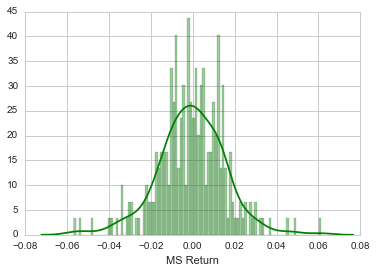

/var/folders/8d/vhbtv_xd50z9q4q9hrxff6500000gp/T/ipykernel_87779/3454888202.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2015']['MS Return'], bins=60)


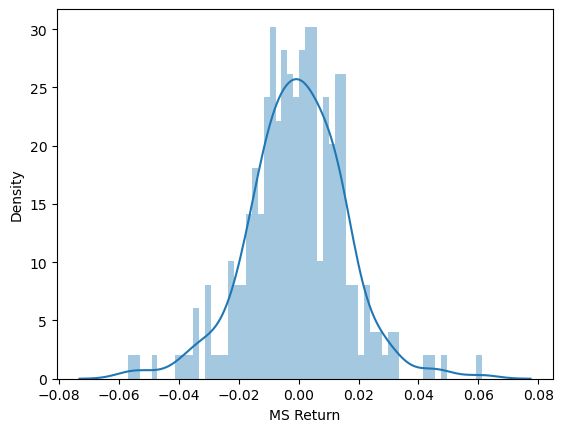

In [61]:
sns.distplot(returns.loc['2015']['MS Return'], bins=60)
plt.show()

** Create a distplot using seaborn of the 2008 returns for CitiGroup **

/Users/marci/anaconda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning:

using a non-integer number instead of an integer will result in an error in the future



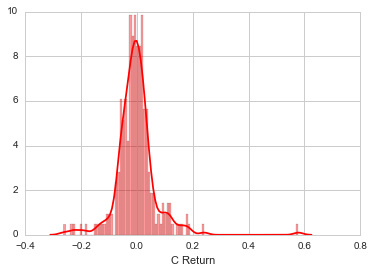

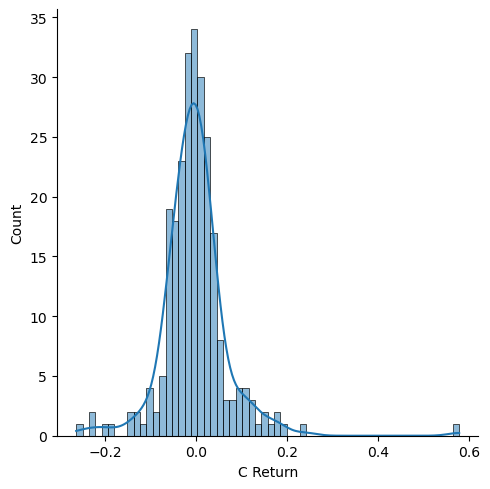

In [63]:
sns.displot(returns.loc['2008']['C Return'], bins=60, kde=True)
plt.show()

____
# More Visualization

A lot of this project will focus on visualizations. Feel free to use any of your preferred visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

### Imports

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

** Create a line plot showing Close price for each bank for the entire index of time. (Hint: Try using a for loop, or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)**

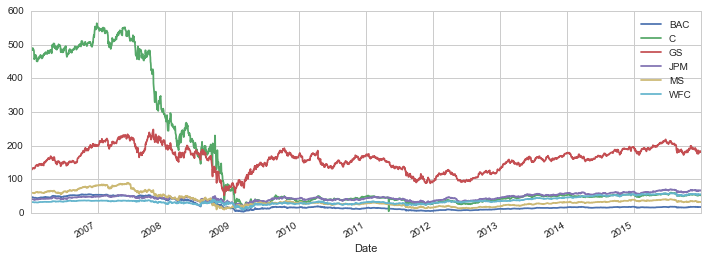

In [67]:
close_price= bank_stocks.xs('Close', level = 'Stock Info', axis=1)

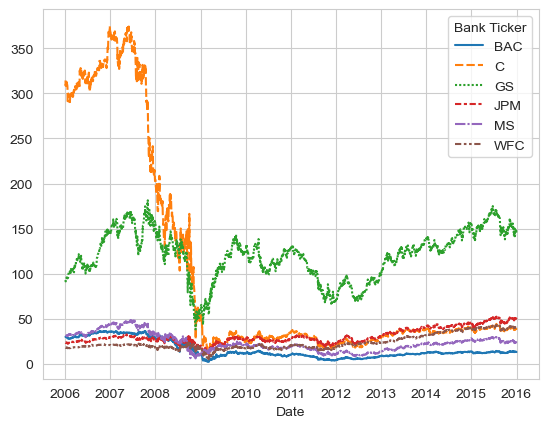

In [69]:
sns.lineplot(close_price)
plt.show()

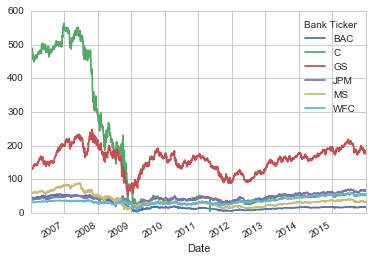

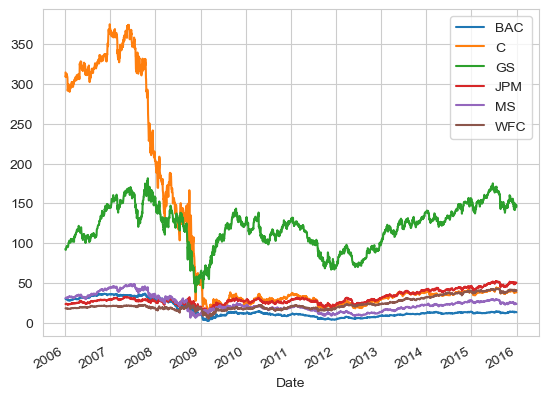

In [71]:
for x in tickers:
    bank_stocks[x]['Close'].plot(label=x)
plt.legend()
plt.show()

## Moving Averages

Let's analyze the moving averages for these stocks in the year 2008. 

** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**

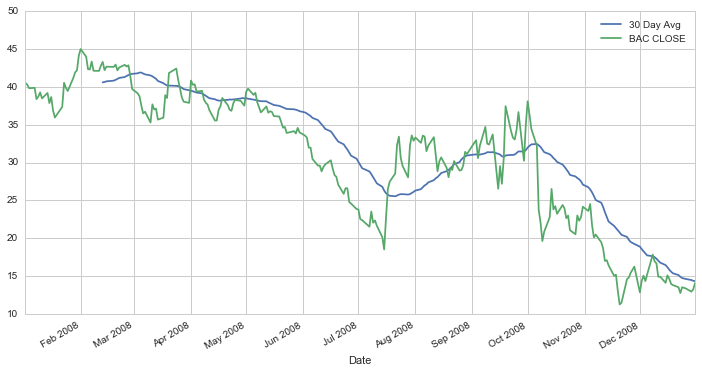

In [73]:
bac = bank_stocks.xs('Close', level = 'Stock Info', axis=1).loc['2008']

In [75]:
bac['bac_mav_30']=bac['BAC'].rolling(window=30).mean()

In [77]:
bac = bac[['BAC','bac_mav_30']]

In [79]:
bac

Bank Ticker,BAC,bac_mav_30
Date,,
2008-01-02,28.634684,NaN
2008-01-03,28.451124,NaN
2008-01-04,28.133448,NaN
2008-01-07,28.168736,NaN
2008-01-08,27.116823,NaN
...,...,...
2008-12-24,10.330662,11.137445
2008-12-26,10.200857,11.054437
2008-12-29,9.880171,10.958252


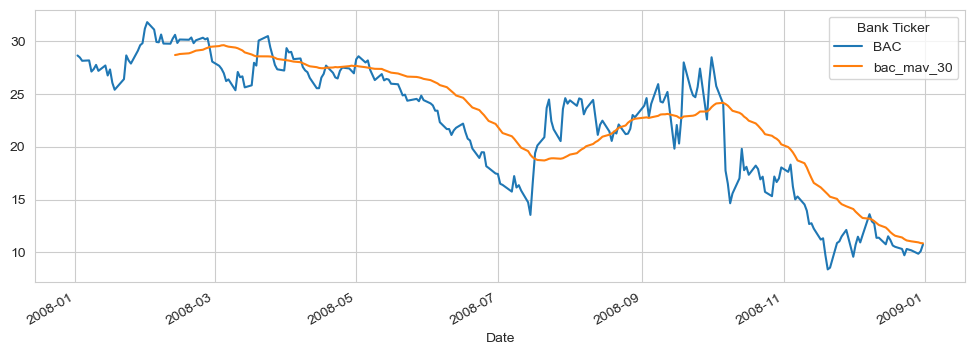

In [81]:
bac.plot.line(figsize=(12,4))
plt.show()

In [5]:
# do a test with microsoft
msft = yf.download("MSFT", start= '2026-01-01', end='2026-06-25')

[*********************100%***********************]  1 of 1 completed


In [7]:
msft = msft.swaplevel(axis=1)

In [13]:
# to get the index slice
idx = pd.IndexSlice
# The ':' means keep all rows, the first 'slice(None)' means keep all outer tickers,
# and ['Close', 'Volume'] isolates your specific inner prices.
msft = msft.loc[:, idx[slice(None), ['Close', 'Volume']]]

In [11]:
import pandas as pd

In [15]:
# Drops the column layer named 'Bank Ticker'
msft = msft.droplevel(level='Ticker', axis=1)

In [211]:
msft

Price,Close,Volume
Date,,
2026-01-02,470.843201,25571600
2026-01-05,470.753632,25250300
2026-01-06,476.388519,23037700
2026-01-07,481.326508,25564200
2026-01-08,475.990265,18162600
...,...,...
2026-06-15,399.760010,32266400
2026-06-16,393.829987,31506800
2026-06-17,378.910004,41987800


In [17]:
msft['mav_10']=msft['Close'].rolling(window=10, min_periods=1).mean()
msft['mav_20']=msft['Close'].rolling(window=20, min_periods=1).mean()
msft['mav_30']=msft['Close'].rolling(window=30, min_periods=1).mean()

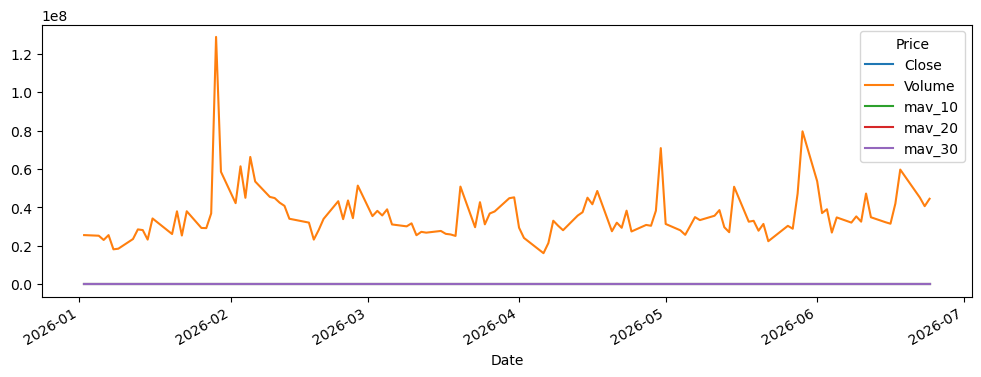

In [29]:
msft.plot.line(figsize=(12,4))
plt.show()
# doesn't work because volume is too high, need 2 different axes

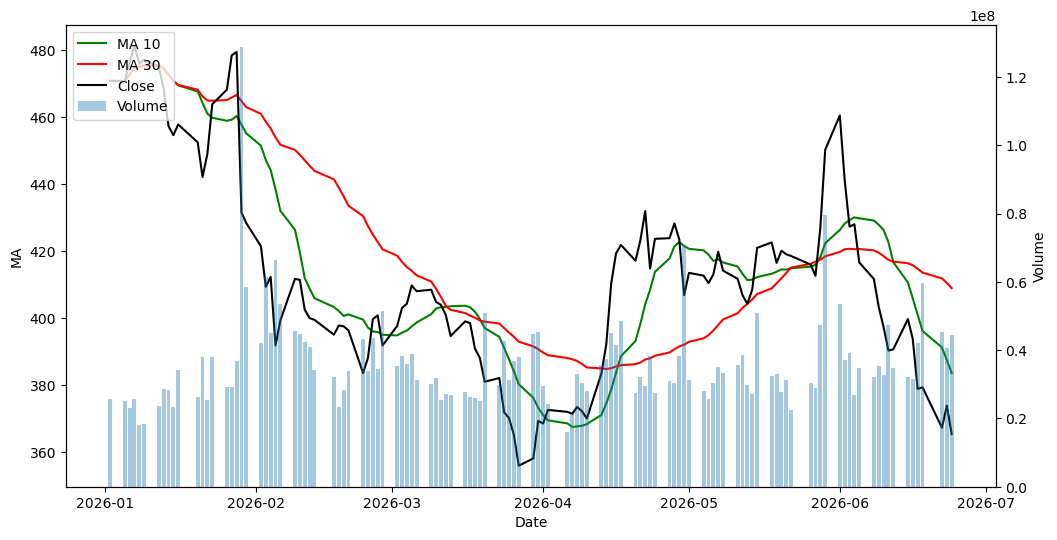

In [25]:
fig, ax1 = plt.subplots(figsize = (12,6))

# line charts
ax1.plot(msft.index, msft['mav_10'], label='MA 10', color = 'green')
ax1.plot(msft.index, msft['mav_30'], label='MA 30', color = 'red')
ax1.plot(msft.index, msft['Close'], label='Close', color = 'black')

# label
ax1.set_ylabel('MA')
ax1.set_xlabel('Date')

# secondary axis for bar chart
ax2 = ax1.twinx()
ax2.bar(msft.index, msft['Volume'], label = 'Volume', alpha = 0.4)
ax2.set_ylabel('Volume')

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

** Create a heatmap of the correlation between the stocks Close Price.**

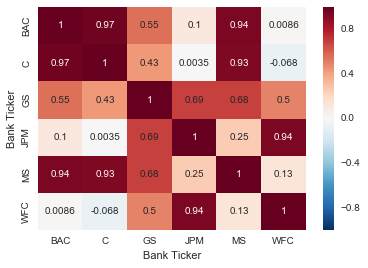

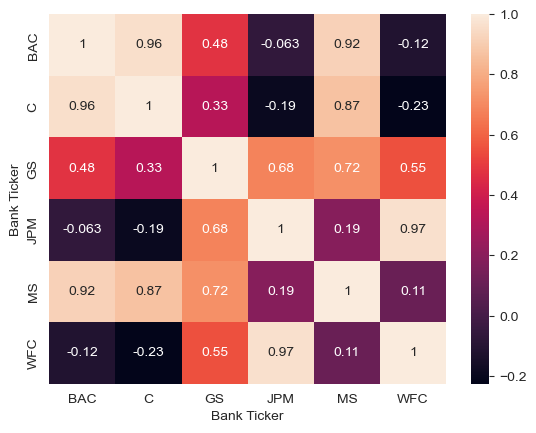

In [97]:
sns.heatmap(df2.corr(), annot=True)
plt.show()

** Optional: Use seaborn's clustermap to cluster the correlations together:**

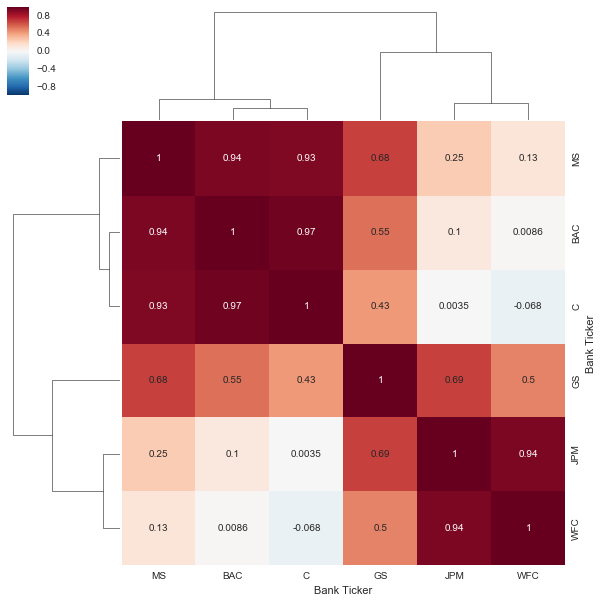

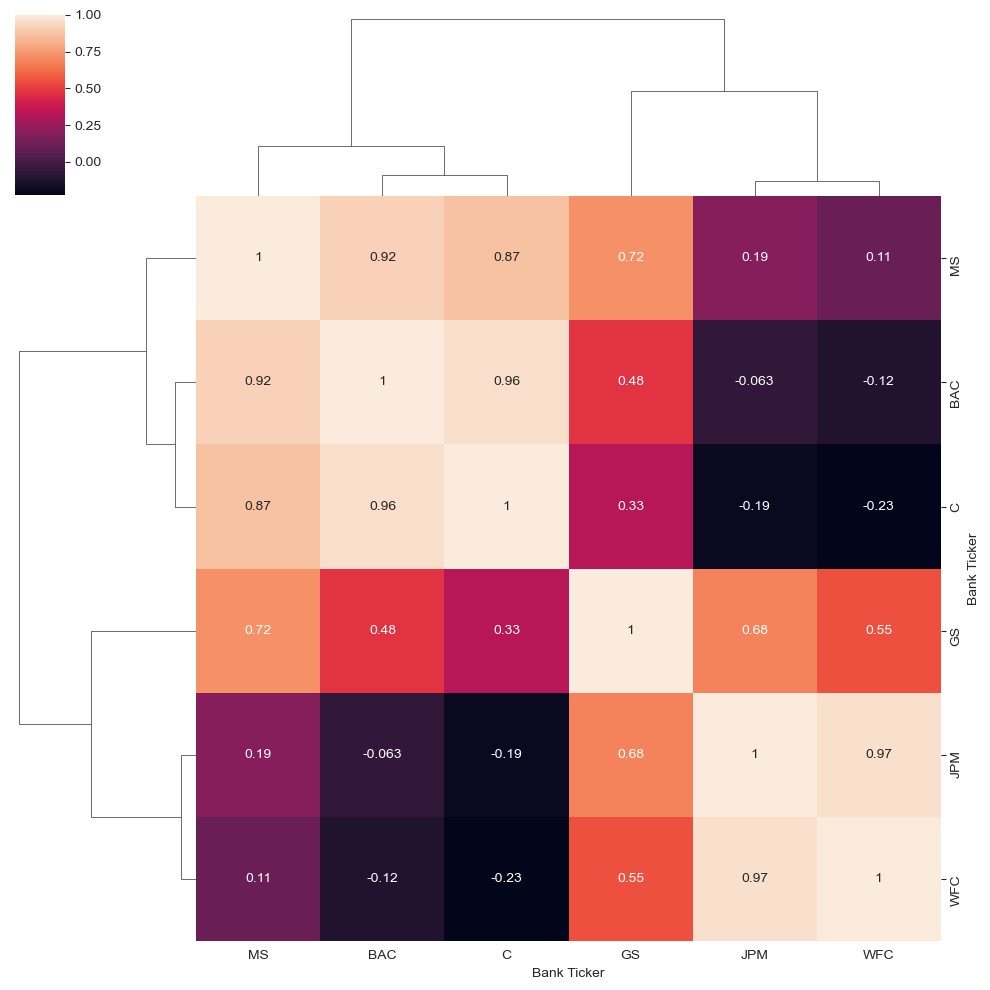

In [99]:
sns.clustermap(df2.corr(), annot=True)
plt.show()

# Part 2 (Optional)

In this second part of the project we will rely on the cufflinks library to create some Technical Analysis plots. This part of the project is experimental due to its heavy reliance on the cuffinks project, so feel free to skip it if any functionality is broken in the future.

** Use .iplot(kind='candle) to create a candle plot of Bank of America's stock from Jan 1st 2015 to Jan 1st 2016.**

In [101]:
import chart_studio.plotly as py
from plotly import __version__
import cufflinks as cf
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
init_notebook_mode(connected=True)

In [103]:
bank_stocks

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Date                                                                            
2006-01-03   30.330349  30.394771  29.731215  30.227270  16296700  314.316803   
2006-01-04   30.008221  30.433412  29.924470  30.278796  17757900  308.513733   
2006-01-05   30.046885  30.169290  29.840731  30.008232  14970700  310.044098   
2006-01-06   30.001791  30.220829  29.860060  30.149964  12599800  310.044098   
2006-01-09   30.021118  30.259485  29.866504  30.098428  15619400  308.577545   
...                ...        ...        ...        ...       ...         ...   
2015-12-24   13.721889  13.809288  13.682160  13.761615  29369400   38.984730   
2015-12-28   13.610649  13.690104  13.491467  13.682159  41777500   38.740639   
2015-12-29   13.729827  13.785445  13.634480  13.705990  45670400   39.184402   
2015-12-30   13.547083  13.698048  13.539139  13.666267  35066400   38.681465   
2015-12-31   13.372282  13.562974  13.372282  13.515301  47153000   38.274685   

Bank Ticker                                                ...         MS  \
Stock Info         High         Low        Open    Volume  ...      Close   
Date                                                       ...              
2006-01-03   314.890719  306.792083  312.467509   1537600  ...  31.182051   
2006-01-04   313.105099  308.322434  311.574650   1870960  ...  31.203430   
2006-01-05   311.064384  308.641176  308.896247   1143160  ...  31.289007   
2006-01-06   311.829618  307.365799  311.702072   1370210  ...  31.321091   
2006-01-09   310.809456  308.003629  309.916695   1680740  ...  31.652639   
...                 ...         ...         ...       ...  ...        ...   
2015-12-24    39.177029   38.792433   38.814620   4671200  ...  24.204792   
2015-12-28    38.881163   38.430002   38.881163   8761700  ...  23.973774   
2015-12-29    39.361909   39.006898   39.021688  10155100  ...  24.256954   
2015-12-30    39.154813   38.644485   39.080854   8763300  ...  24.018480   
2015-12-31    38.748033   38.274685   38.511359  11281800  ...  23.705486   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Date                                                                          
2006-01-03   31.278308  30.342472  30.572419  5377000  18.274656  18.317622   
2006-01-04   31.700760  31.203430  31.390599  7977800  18.062706  18.228839   
2006-01-05   31.331789  31.026974  31.310398  5778000  18.042645  18.077017   
2006-01-06   31.470824  31.043013  31.428044  6889800  18.148634  18.203057   
2006-01-09   31.706117  31.347824  31.353173  4144500  18.145760  18.231691   
...                ...        ...        ...      ...        ...        ...   
2015-12-24   24.376193  24.174982  24.271862  2798200  40.900063  41.101504   
2015-12-28   24.115368  23.809827  24.115368  5420300  40.795612  40.870219   
2015-12-29   24.368739  24.093007  24.174979  6388200  41.250732  41.295495   
2015-12-30   24.331475  23.996125  24.219690  5057200  40.952282  41.265637   
2015-12-31   24.070645  23.675678  23.780009  8154300  40.556873  40.997060   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Date                                         
2006-01-03   17.870781  18.102795  11016400  
2006-01-04   17.968181  18.217381  10870000  
2006-01-05   17.936662  18.045508  10158000  
2006-01-06   17.979636  18.091346   8403800  
2006-01-09   18.077015  18.145760   5619600  
...                ...        ...       ...  
2015-12-24   40.817993  41.011976   4999400  
2015-12-28   40.415110  40.698621   8288800  
2015-12-29   41.026909  41.116438   7894900  
2015-12-30   40.877675  41.235793   8016900  
2015-12-31   40.452423  40.668784  10929800  

[2517 rows x 30 columns]

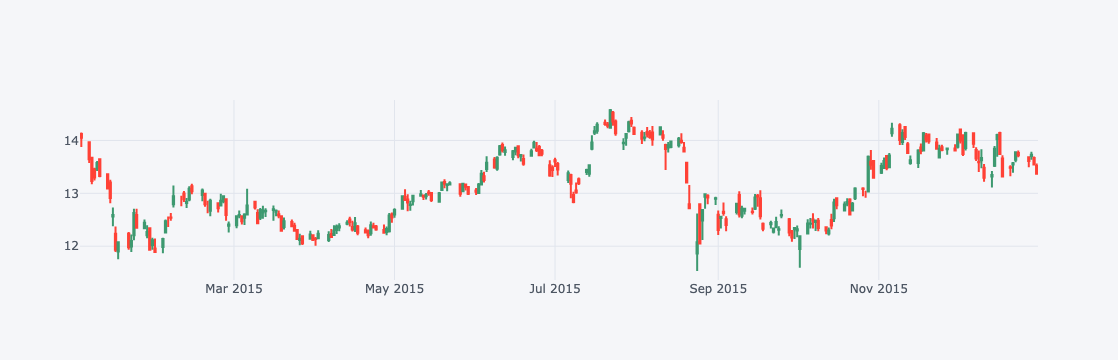

In [105]:

bank_stocks.xs('BAC',level = 'Bank Ticker', axis=1).loc['2015'].iplot(kind='candle')

** Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.**

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



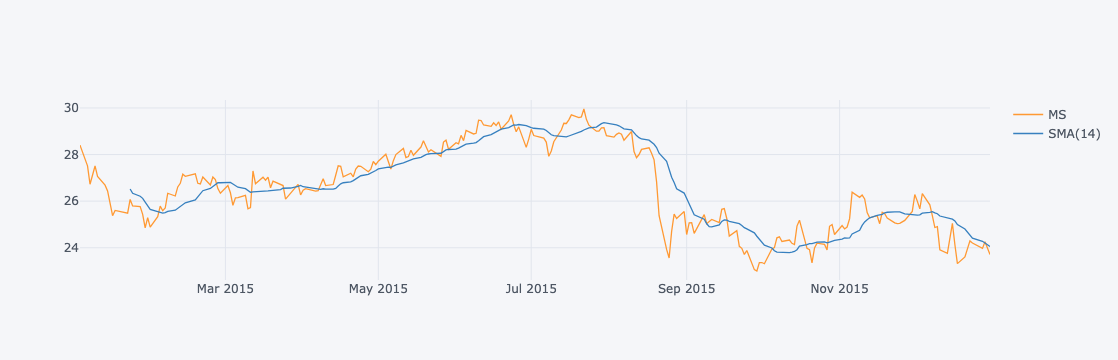

In [107]:
bank_stocks.xs('Close',level = 'Stock Info', axis=1)['MS'].loc['2015'].ta_plot(study='sma')

In [109]:
bank_stocks.xs('Close',level = 'Stock Info', axis=1)['MS'].loc['2015']

Date
2015-01-02    28.405537
2015-01-05    27.517618
2015-01-06    26.725122
2015-01-07    27.106703
2015-01-08    27.510284
                ...    
2015-12-24    24.204792
2015-12-28    23.973774
2015-12-29    24.256954
2015-12-30    24.018480
2015-12-31    23.705486
Name: MS, Length: 252, dtype: float64

**Use .ta_plot(study='boll') to create a Bollinger Band Plot for Bank of America for the year 2015.**

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



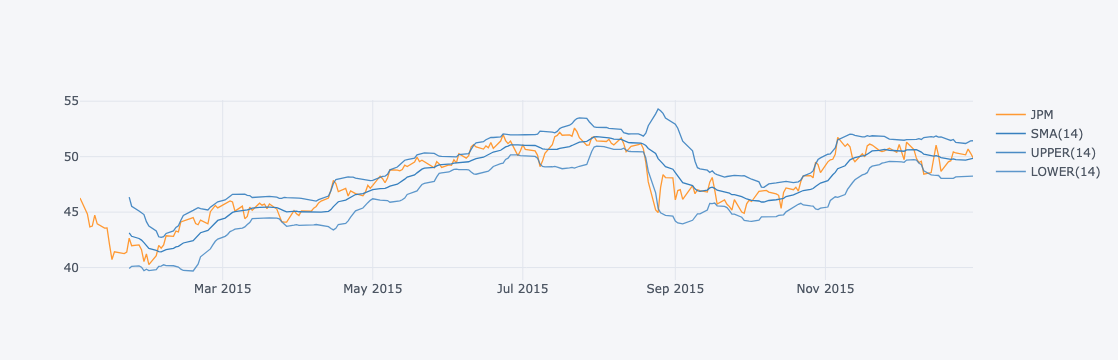

In [111]:
bank_stocks.xs('Close',level = 'Stock Info', axis=1)['JPM'].loc['2015'].ta_plot(study='boll')

# Great Job!

Definitely a lot of more specific finance topics here, so don't worry if you didn't understand them all! The only thing you should be concerned with understanding are the basic pandas and visualization oeprations.